In [1]:
%matplotlib inline
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

In [2]:
img_dir  = "data/Kvasir-SEG/images"
mask_dir = "data/Kvasir-SEG/masks"

name = os.listdir(img_dir)[0]

img  = Image.open(f"{img_dir}/{name}")
mask = Image.open(f"{mask_dir}/{name}")

print("Image name :", name)
print("Image size :", img.size)
print("Image mode :", img.mode)
print("Mask size  :", mask.size)
print("Mask mode  :", mask.mode)

Image name : cju5wi6bqlxy90755bu227nvb.jpg
Image size : (622, 530)
Image mode : RGB
Mask size  : (622, 530)
Mask mode  : RGB


In [3]:
mask_arr = np.array(mask)
print("Min value  :", mask_arr.min())
print("Max value  :", mask_arr.max())
print("Unique values:", np.unique(mask_arr))

Min value  : 0
Max value  : 255
Unique values: [  0   1   2   3   4   5   6   7 248 249 250 251 252 253 254 255]


Unique values after binarize: [0 1]


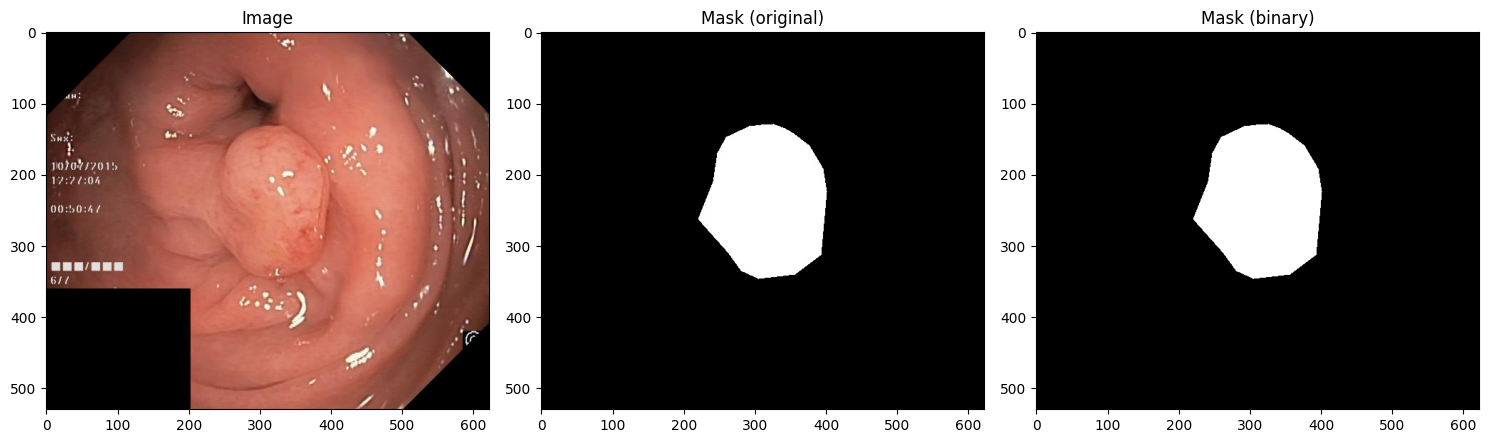

In [7]:
# Load the mask as a numpy array to inspect its pixel values
mask_arr = np.array(mask)

# Binarize the mask: JPEG compression introduces intermediate values (1,2,3...253,254)
# at the edges between black and white regions.
# We fix this by thresholding: any pixel < 127 becomes 0 (polyp), rest becomes 1 (background)
binary_mask = (mask_arr > 127).astype(np.uint8)

print("Unique values after binarize:", np.unique(binary_mask))

# Visualize original vs binarized mask side by side
binary_mask_display = (binary_mask * 255).astype(np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img)
axes[0].set_title("Image")
axes[1].imshow(mask, cmap="gray")
axes[1].set_title("Mask (original)")
axes[2].imshow(binary_mask_display, cmap="gray")
axes[2].set_title("Mask (binary)")
plt.tight_layout()
plt.show()



In [8]:
# Calculate what fraction of the image is polyp (foreground)
# This tells us how severe the class imbalance is.
# If the polyp covers only ~5% of pixels, a model that predicts
# "all background" gets 95% pixel accuracy but is completely useless.
# This is why we use Dice loss instead of plain cross-entropy.
polyp_ratio = binary_mask.sum() / binary_mask.size
print(f"Polyp coverage: {polyp_ratio:.2%}")

Polyp coverage: 8.91%


## Step 2: Dataset & DataLoaders

In [ ]:
import torch
from dataset import build_dataloaders

IMG_DIR  = "data/Kvasir-SEG/images"
MASK_DIR = "data/Kvasir-SEG/masks"

train_loader, val_loader, test_loader = build_dataloaders(
    img_dir=IMG_DIR,
    mask_dir=MASK_DIR,
    batch_size=8,
    num_workers=2,
)

In [ ]:
print(f"Train: {len(train_loader.dataset)} samples, {len(train_loader)} batches")
print(f"Val  : {len(val_loader.dataset)} samples")
print(f"Test : {len(test_loader.dataset)} samples")

imgs, masks = next(iter(train_loader))
print(f"\nImage batch shape : {imgs.shape}   dtype: {imgs.dtype}")
print(f"Mask  batch shape : {masks.shape}  dtype: {masks.dtype}")
print(f"Image value range : [{imgs.min():.3f}, {imgs.max():.3f}]")
print(f"Mask unique values: {masks.unique().tolist()}")

assert imgs.shape  == (8, 3, 256, 256)
assert masks.shape == (8, 1, 256, 256)
assert imgs.dtype  == torch.float32
assert masks.dtype == torch.float32
assert set(masks.unique().tolist()).issubset({0.0, 1.0})
assert len(train_loader.dataset) == 800
assert len(val_loader.dataset)   == 100
assert len(test_loader.dataset)  == 100
print("\nAll assertions passed.")

In [ ]:
from dataset import split_dataset

train_paths = set(train_loader.dataset.img_paths)
val_paths   = set(val_loader.dataset.img_paths)
test_paths  = set(test_loader.dataset.img_paths)

assert len(train_paths & val_paths)  == 0
assert len(train_paths & test_paths) == 0
assert len(val_paths   & test_paths) == 0
print("No overlap between splits.")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def denormalize(tensor):
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img  = tensor.numpy().transpose(1, 2, 0)  # [C,H,W] -> [H,W,C]
    return np.clip(img * std + mean, 0, 1)

img_t, mask_t = imgs[0], masks[0]
img_disp  = denormalize(img_t)
mask_disp = mask_t.squeeze().numpy()

overlay = img_disp.copy()
overlay[mask_disp == 1, 0] = 1.0   # red channel max where polyp
overlay[mask_disp == 1, 1] *= 0.3
overlay[mask_disp == 1, 2] *= 0.3

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img_disp);             axes[0].set_title("Image (denorm)")
axes[1].imshow(mask_disp, cmap="gray"); axes[1].set_title("Binary Mask")
axes[2].imshow(overlay);              axes[2].set_title("Overlay")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()